In [5]:
import pandas as pd
import pickle

from sklearn.linear_model import LinearRegression

# Load Dataset
df = pd.read_csv("/content/Symptom2Disease.csv")

# Create Features
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['text_length'] = df['text'].apply(len)

# Input and Output
X = df[['word_count']]
y = df['text_length']

# Train Model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

SAVE MODEL AS PICKLE

In [12]:
import pickle

In [13]:
with open('model_pickle', 'wb') as file:
    pickle.dump(model, file)


In [14]:
with open('model_pickle', 'rb') as file:
    mp = pickle.load(file)


In [15]:
print(mp.coef_)

[  0.06327731 -11.31466387  -1.27079832  14.12466387  -4.36693277
  -3.80693277  12.10079832  -7.37466387   5.05306723  17.62466387
  -1.39920168  -3.97079832  -1.37079832  -7.67466387  -4.22306723
   8.01693277   6.98466387   0.13693277   2.36079832   0.32079832
 -13.49466387  -6.94693277  -0.18306723  -7.67079832   8.34466387]


In [16]:
print(mp.intercept_)

21.265042016806994


In [18]:
print(mp.predict([X.iloc[0]]))

[np.float64(28.249705882353215)]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


SAVE MODEL AS JOBLIB


In [2]:
import joblib

In [6]:
joblib.dump(model, 'model_joblib')

['model_joblib']

In [7]:
mj = joblib.load('model_joblib')

In [8]:
mj.coef_

array([4.78223742])

In [9]:
mj.intercept_

np.float64(24.94242179859748)

In [10]:
mj.predict([[5000]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([23936.12954435])

ONE HOT ENCODING

In [11]:
import pandas as pd

from sklearn.linear_model import LinearRegression

# Load Dataset
df = pd.read_csv("/content/Symptom2Disease.csv")

# Display Dataset
print(df.head())

# Create Word Count Feature
df['word_count'] = df['text'].apply(
    lambda x: len(str(x).split())
)

# One Hot Encoding for Disease Labels
dummies = pd.get_dummies(df['label'])

# Merge Dataset
merged = pd.concat([df, dummies], axis='columns')

# Display Merged Dataset
print(merged.head())

# Drop Original Label Column
final = merged.drop(['label', 'text'], axis='columns')

# Display Final Dataset
print(final.head())

# Features
X = final.drop('word_count', axis='columns')

# Target
y = final['word_count']

# Create Model
model = LinearRegression()

# Train Model
model.fit(X, y)

# Model Score
print(model.score(X, y))

# Sample Prediction
print(model.predict([X.iloc[0]]))

   Unnamed: 0      label                                               text
0           0  Psoriasis  I have been experiencing a skin rash on my arm...
1           1  Psoriasis  My skin has been peeling, especially on my kne...
2           2  Psoriasis  I have been experiencing joint pain in my fing...
3           3  Psoriasis  There is a silver like dusting on my skin, esp...
4           4  Psoriasis  My nails have small dents or pits in them, and...
   Unnamed: 0      label                                               text  \
0           0  Psoriasis  I have been experiencing a skin rash on my arm...   
1           1  Psoriasis  My skin has been peeling, especially on my kne...   
2           2  Psoriasis  I have been experiencing joint pain in my fing...   
3           3  Psoriasis  There is a silver like dusting on my skin, esp...   
4           4  Psoriasis  My nails have small dents or pits in them, and...   

   word_count   Acne  Arthritis  Bronchial Asthma  Cervical spondylos

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


TRAIN AND TEST SPLITTING

In [21]:
import pandas as pd

# Load Dataset
df = pd.read_csv("/content/Symptom2Disease.csv")

# Display Dataset
df.head()

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."


In [22]:
import matplotlib.pyplot as plt
%matplotlib inline

In [23]:
# Create Features
df['word_count'] = df['text'].apply(
    lambda x: len(str(x).split())
)

df['text_length'] = df['text'].apply(len)

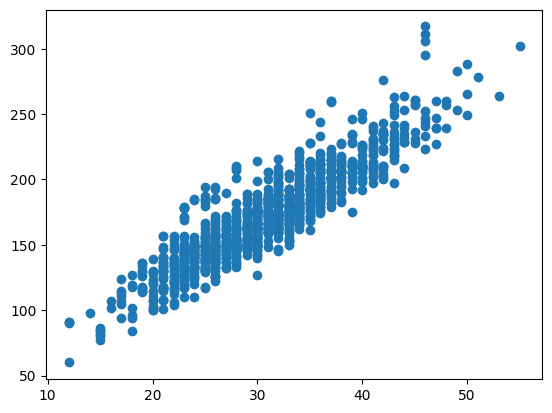

In [24]:
# Word Count Vs Text Length

plt.scatter(df['word_count'], df['text_length'])

In [25]:
# Features
X = df[['word_count']]

# Target
y = df['text_length']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3
)

In [27]:
X_train

,word_count
201,31
645,43
116,29
237,36
212,32
...,...
329,46
78,35
422,40
45,25


In [28]:
X_test

,word_count
24,26
221,32
361,33
874,29
73,30
...,...
1102,33
454,37
147,31
483,40


In [29]:
y_train

,text_length
201,181
645,263
116,177
237,187
212,167
...,...
329,241
78,183
422,192
45,159


In [30]:
y_test

,text_length
24,145
221,170
361,170
874,165
73,160
...,...
1102,182
454,207
147,160
483,226


In [31]:
# Lets run linear regression model now

from sklearn.linear_model import LinearRegression

clf = LinearRegression()

clf.fit(X_train, y_train)

LinearRegression()

In [32]:
X_test

,word_count
24,26
221,32
361,33
874,29
73,30
...,...
1102,33
454,37
147,31
483,40


In [33]:
clf.predict(X_test)

array([149.3049096 , 177.86632929, 182.6265659 , 163.58561944,
       168.34585606, 149.3049096 , 211.1879856 , 268.31082498,
       187.38680252, 225.46869544, 149.3049096 , 225.46869544,
       206.42774898, 196.90727575, 139.78443637, 111.22301668,
       158.82538283, 201.66751237, 168.34585606, 254.03011513,
       177.86632929, 158.82538283, 211.1879856 , 168.34585606,
       149.3049096 , 135.02419975, 220.70845883, 139.78443637,
       158.82538283, 187.38680252, 192.14703913, 201.66751237,
       163.58561944, 173.10609267, 168.34585606, 163.58561944,
       154.06514621, 211.1879856 , 139.78443637, 168.34585606,
       130.26396314, 149.3049096 , 135.02419975, 187.38680252,
       106.46278006, 263.55058836, 196.90727575, 139.78443637,
       206.42774898, 215.94822221, 163.58561944, 139.78443637,
       154.06514621, 154.06514621, 158.82538283, 154.06514621,
       158.82538283, 163.58561944, 144.54467298, 215.94822221,
       177.86632929, 201.66751237, 192.14703913, 196.90

In [34]:
y_test

,text_length
24,145
221,170
361,170
874,165
73,160
...,...
1102,182
454,207
147,160
483,226


In [35]:
clf.score(X_test, y_test)

0.808650220187747

In [36]:
# random_state argument

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=10
)

X_test

,word_count
123,27
1036,32
1034,22
426,42
726,28
...,...
805,37
968,25
411,38
10,26
